<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = "cpu"
device

2.5.0


'mps'

#### 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [12]:
import os 
os.getcwd()

'/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning'

In [16]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

# Set Path to data folder
data_path = Path('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():
    print(f'{image_path} directory exists.')
else:
    print(f'Did not find {image_path} directory, creating one...')
    image_path.mkdir(parents= True, exist_ok= True)

Did not find /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi directory, creating one...


In [17]:
# 1.1 Downloading Data from Github
with open(data_path / "pizza_steak_sushi.zip", 'wb') as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print('Downloading...')
    f.write(request.content)

# 1.2 Unzip Data
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print(f'Unzipping...')
    zip_ref.extractall(image_path)

Downloading...
Unzipping...


In [18]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [19]:
walk_through_dir(image_path)

There are 2 directories and 0 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi'.
There are 3 directories and 0 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test'.
There are 0 directories and 19 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/train'.
There are 0 directories and 75 images in '/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/train/steak'.
Th

In [20]:
# Setup train and testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'
train_dir, test_dir

(PosixPath('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/train'),
 PosixPath('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test'))

[PosixPath('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/steak/296375.jpg'), PosixPath('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/steak/673127.jpg'), PosixPath('/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/steak/894825.jpg')]
/Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/sushi/1230335.jpg
sushi
Random image path: /Users/user/Desktop/Zero to Mastery Learn PyTorch for Deep Learning/Data/pizza_steak_sushi/test/sushi/1230335.jpg
Image class: sushi
Image height: 384
Image width: 512


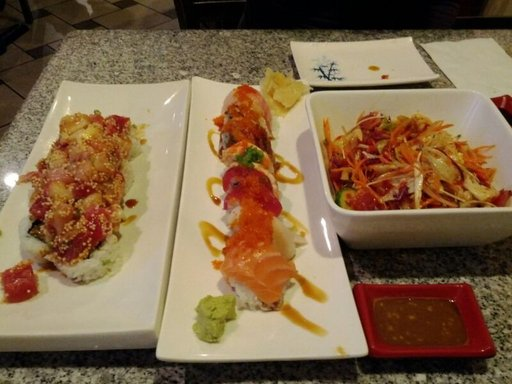

In [27]:
# Visualize an image
import random
from PIL import Image

# Create Path List
image_path_list = list(image_path.glob('*/*/*.jpg'))
print(image_path_list[:3])

# Random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

# Identify class for the random image
image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)

print(f'Random image path: {random_image_path}')
print(f'Image class: {image_class}')
print(f'Image height: {img.height}')
print(f'Image width: {img.width}')
img

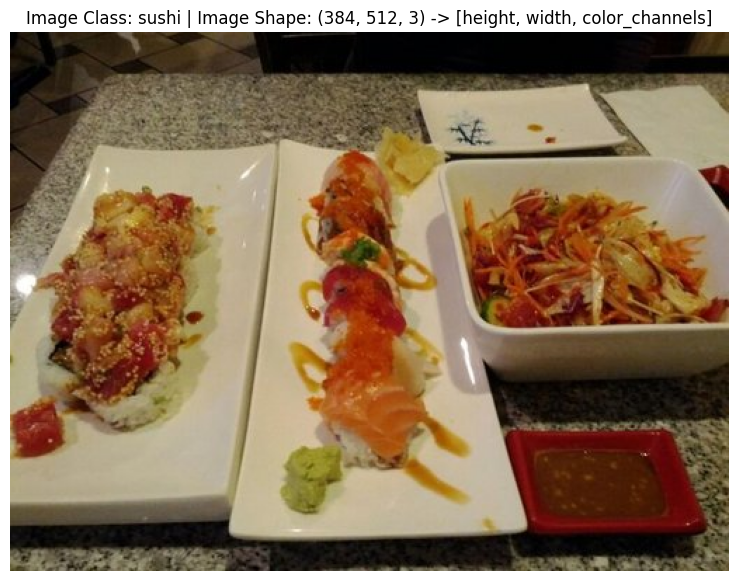

In [30]:
# Do the image visualization with matplotlib
import numpy as np 
import matplotlib.pyplot as plt

img_as_array = np.array(img)

plt.figure(figsize = (10, 7))
plt.imshow(img_as_array)
plt.title(f'Image Class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, color_channels]')
plt.axis(False)
plt.show()

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [31]:
# 3.1 Transforming data with torchvision.transforms
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [32]:
# Write transform for turning images into tensors
data_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5), 
    transforms.ToTensor()
])

In [42]:
# Write a function to plot transformed images
from matplotlib.pyplot import imshow


def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k = n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows = 1, ncols= 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nsize: {f.size}")
            ax[0].axis("off")

            # Transform Image
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nsize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


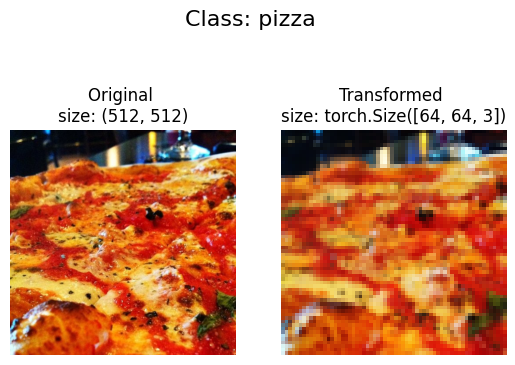

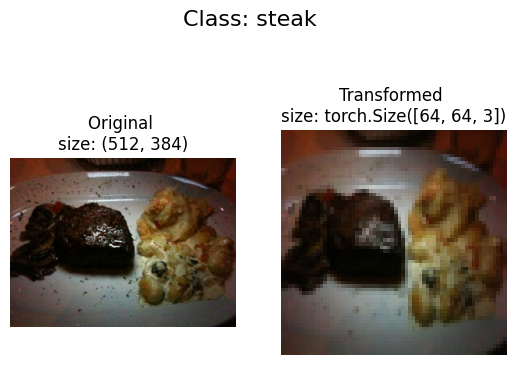

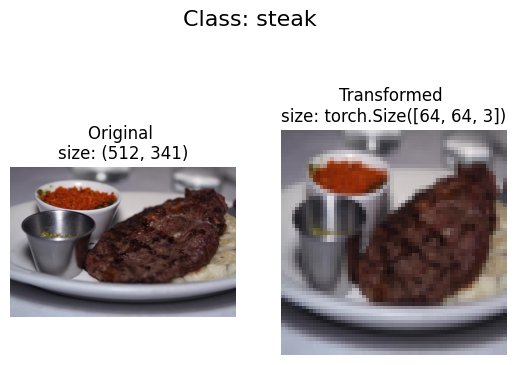

In [43]:
plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

### Load image data using `ImageFolder`

In [33]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform,
                                  target_transform = None)
 
test_data = datasets.ImageFolder(root = test_dir, 
                                 transform= data_transform,
                                 target_transform= None)

In [34]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [35]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [36]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [37]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset = train_data, 
                              batch_size = BATCH_SIZE,
                              num_workers = os.cpu_count(),
                              shuffle = True)


test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE, 
                             num_workers= os.cpu_count(),
                             shuffle = False)

In [39]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(225, 75)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [63]:
class TinyVGG(nn.Module):
    def __init__(self,
                 input_shape,
                 hidden_units,
                 output_shape):
        super().__init__()
        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape, 
                      out_channels= hidden_units, 
                      kernel_size= 3, 
                      stride= 1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units, 
                      out_channels= hidden_units,
                      kernel_size= 3, 
                      stride= 1, 
                      padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2)
        )
        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3, 
                      stride= 1 , 
                      padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3, 
                      stride= 1, 
                      padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_units * 16 * 16, 
                      out_features= output_shape)
        )
    
    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.classifier(x)
        return x

In [65]:
model = TinyVGG(input_shape= 3,
                hidden_units= 10,
                output_shape= len(class_names)).to(device)
model

TinyVGG(
  (conv_layer1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

## 4. Create training and testing functions for `model_0`.

In [66]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)
    # 1. Forward pass
    y_pred_logits = model(X)
    y_pred_labels = torch.argmax(y_pred_logits, dim= 1)
    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred_logits, y)
    train_loss += loss.item()

    train_acc += ((y_pred_labels == y).sum().item()/ len(y_pred_labels))
    # 3. Optimizer zero grad 
    optimizer.zero_grad()

    # 4. Loss backward 
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  return train_loss, train_acc
  # Adjust metrics to get average loss and average accuracy per batch
  

In [67]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  
  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():

    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred_logits = model(X)
      y_pred_labels = torch.argmax(y_pred_logits, dim = 1)
      # 2. Calculuate and accumulate loss
      loss = loss_fn(y_pred_logits, y)
      test_loss += loss.item()
      # Calculate and accumulate accuracy
      test_acc += ((y_pred_labels == y).sum().item()/len(y_pred_labels))
    
  # Adjust metrics to get average loss and accuracy per batch
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  return test_loss, test_acc


In [68]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer. 

In [70]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = TinyVGG(input_shape= 3,
                hidden_units= 10, 
                output_shape= len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=0.001)

model_5epoch_result = train(model= model,
                            train_dataloader= train_dataloader,
                            test_dataloader= test_dataloader,
                            optimizer= optimizer,
                            epochs= 5)

 20%|██        | 1/5 [01:27<05:50, 87.55s/it]

Epoch: 1 | train_loss: 1.1180 | train_acc: 0.2800 | test_loss: 1.0971 | test_acc: 0.3333


 40%|████      | 2/5 [02:56<04:25, 88.48s/it]

Epoch: 2 | train_loss: 1.0999 | train_acc: 0.3022 | test_loss: 1.0993 | test_acc: 0.2533


 60%|██████    | 3/5 [04:25<02:56, 88.50s/it]

Epoch: 3 | train_loss: 1.0992 | train_acc: 0.3289 | test_loss: 1.0996 | test_acc: 0.3333


 80%|████████  | 4/5 [05:55<01:29, 89.06s/it]

Epoch: 4 | train_loss: 1.0989 | train_acc: 0.3333 | test_loss: 1.0999 | test_acc: 0.3333


100%|██████████| 5/5 [07:23<00:00, 88.80s/it]

Epoch: 5 | train_loss: 1.0989 | train_acc: 0.3333 | test_loss: 1.0999 | test_acc: 0.3333


In [72]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model0_20 = TinyVGG(input_shape= 3,
                hidden_units= 10, 
                output_shape= len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0_20.parameters(), 
                             lr=0.001)

model_20epoch_result = train(model= model0_20,
                            train_dataloader= train_dataloader,
                            test_dataloader= test_dataloader,
                            optimizer= optimizer,
                            epochs= 20)

  5%|▌         | 1/20 [01:27<27:42, 87.48s/it]

Epoch: 1 | train_loss: 1.1180 | train_acc: 0.2800 | test_loss: 1.0971 | test_acc: 0.3333


 10%|█         | 2/20 [02:54<26:14, 87.50s/it]

Epoch: 2 | train_loss: 1.0999 | train_acc: 0.3022 | test_loss: 1.0993 | test_acc: 0.2533


 15%|█▌        | 3/20 [04:22<24:47, 87.50s/it]

...

Epoch: 18 | train_loss: 0.5062 | train_acc: 0.7867 | test_loss: 1.4886 | test_acc: 0.5200


 95%|█████████▌| 19/20 [27:39<01:27, 87.32s/it]

Epoch: 19 | train_loss: 0.4964 | train_acc: 0.7867 | test_loss: 1.3672 | test_acc: 0.5600


100%|██████████| 20/20 [29:06<00:00, 87.32s/it]

Epoch: 20 | train_loss: 0.3637 | train_acc: 0.8533 | test_loss: 1.4284 | test_acc: 0.5600


In [73]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model0_50 = TinyVGG(input_shape= 3,
                hidden_units= 10, 
                output_shape= len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0_50.parameters(), 
                             lr=0.001)
model_50epoch_result = train(model= model0_50,
                            train_dataloader= train_dataloader,
                            test_dataloader= test_dataloader,
                            optimizer= optimizer,
                            epochs= 50)

  2%|▏         | 1/50 [01:27<1:11:04, 87.03s/it]

Epoch: 1 | train_loss: 1.1180 | train_acc: 0.2800 | test_loss: 1.0971 | test_acc: 0.3333


  4%|▍         | 2/50 [02:54<1:09:40, 87.10s/it]

Epoch: 2 | train_loss: 1.0999 | train_acc: 0.3022 | test_loss: 1.0993 | test_acc: 0.2533


  6%|▌         | 3/50 [04:21<1:08:14, 87.12s/it]

...

Epoch: 48 | train_loss: 0.0006 | train_acc: 1.0000 | test_loss: 5.3817 | test_acc: 0.5200


 98%|█████████▊| 49/50 [1:11:02<01:26, 86.52s/it]

Epoch: 49 | train_loss: 0.0005 | train_acc: 1.0000 | test_loss: 5.6793 | test_acc: 0.5333


100%|██████████| 50/50 [1:12:29<00:00, 86.98s/it]

Epoch: 50 | train_loss: 0.0006 | train_acc: 1.0000 | test_loss: 6.2274 | test_acc: 0.4933


It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [74]:
# Double the number of hidden units and train for 20 epochs
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model0_20_2 = TinyVGG(input_shape= 3,
                hidden_units= 20, 
                output_shape= len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0_20_2.parameters(), 
                             lr=0.001)

model_20epoch_result_2 = train(model= model0_20_2,
                            train_dataloader= train_dataloader,
                            test_dataloader= test_dataloader,
                            optimizer= optimizer,
                            epochs= 20)


  5%|▌         | 1/20 [01:28<28:04, 88.68s/it]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.4044 | test_loss: 1.0561 | test_acc: 0.4400


 10%|█         | 2/20 [02:56<26:31, 88.39s/it]

Epoch: 2 | train_loss: 1.0041 | train_acc: 0.5556 | test_loss: 1.0082 | test_acc: 0.4400


 15%|█▌        | 3/20 [04:24<24:54, 87.89s/it]

...

Epoch: 18 | train_loss: 0.2553 | train_acc: 0.9022 | test_loss: 2.0121 | test_acc: 0.5067


 95%|█████████▌| 19/20 [27:41<01:27, 87.16s/it]

Epoch: 19 | train_loss: 0.2691 | train_acc: 0.9067 | test_loss: 1.8818 | test_acc: 0.5067


100%|██████████| 20/20 [29:08<00:00, 87.44s/it]

Epoch: 20 | train_loss: 0.1695 | train_acc: 0.9467 | test_loss: 2.3755 | test_acc: 0.5600


It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [75]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...") 
    zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [76]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 1 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 1 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 3 directories and 1 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.


Excellent, we now have double the training and testing images... 

In [77]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [78]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),                                     
  transforms.ToTensor()
])

# Create datasets
train_data_20_percent = ImageFolder(train_data_20_percent_path, 
                                    transform= simple_transform,
                                    target_transform= None)
test_data_20_percent = ImageFolder(test_data_20_percent_path,
                                   transform= simple_transform,
                                   target_transform= None)
# Create dataloaders
train_dataloader_20_percent = DataLoader(train_data_20_percent, 
                                         batch_size= 32, 
                                         num_workers= os.cpu_count(),
                                         shuffle= True)

test_dataloader_20_percent = DataLoader(test_data_20_percent,
                                        batch_size= 32,
                                        num_workers= os.cpu_count(),
                                        shuffle= False)


In [79]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_more_data = TinyVGG(input_shape=3, 
                          hidden_units= 20, 
                          output_shape= len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_more_data.parameters(),
                             lr = 0.001)

model_more_data_results = train(model = model_more_data,
                                train_dataloader= train_dataloader_20_percent,
                                test_dataloader= test_dataloader_20_percent, 
                                optimizer= optimizer,
                                loss_fn= loss_fn,
                                epochs= 20)

  5%|▌         | 1/20 [01:13<23:18, 73.63s/it]

Epoch: 1 | train_loss: 1.1042 | train_acc: 0.3312 | test_loss: 1.1004 | test_acc: 0.2875


 10%|█         | 2/20 [02:25<21:46, 72.58s/it]

Epoch: 2 | train_loss: 1.0832 | train_acc: 0.3917 | test_loss: 1.0690 | test_acc: 0.4256


 15%|█▌        | 3/20 [03:36<20:24, 72.01s/it]

...

Epoch: 18 | train_loss: 0.3859 | train_acc: 0.8458 | test_loss: 1.3044 | test_acc: 0.5284


Python(19991) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19992) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19993) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19994) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19995) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19996) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19997) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19998) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20034) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20035) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20036) Malloc

Epoch: 19 | train_loss: 0.3046 | train_acc: 0.8792 | test_loss: 1.3037 | test_acc: 0.5403


Python(20087) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20088) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20090) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20091) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20092) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20093) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20094) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20095) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20167) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20169) Malloc

Epoch: 20 | train_loss: 0.2858 | train_acc: 0.8938 | test_loss: 1.3063 | test_acc: 0.5716


## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?

In [105]:
# Get a custom image
custom_image = "pizza_dad.jpeg"
with open("pizza_dad.jpeg", "wb") as f:
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
  f.write(request.content)

In [106]:
import torchvision
img = torchvision.io.read_image(custom_image)

img.shape

torch.Size([3, 4032, 3024])

(-0.5, 3023.5, 4031.5, -0.5)

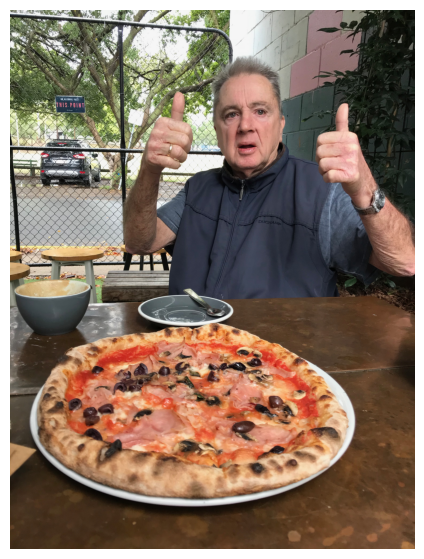

In [107]:
plt.figure(figsize=(10,7))
plt.imshow(img.permute(1, 2, 0))
plt.axis(False)

(-0.5, 63.5, 63.5, -0.5)

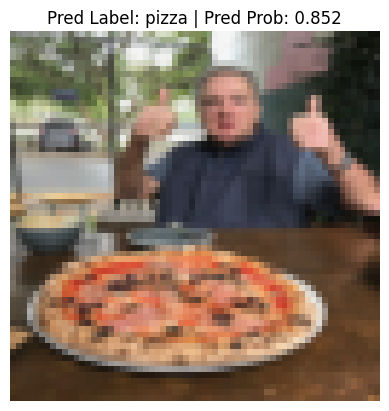

In [108]:
model_more_data.eval()
with torch.inference_mode():
    img = img/255.

    resize = transforms.Resize(size=(64, 64))
    img = resize(img)

    batch = img.unsqueeze(0).to(device)

    y_pred_logits = model_more_data(batch)

    y_pred_prob = torch.softmax(y_pred_logits, dim= 1)

    y_pred_label = torch.argmax(y_pred_prob, dim = 1)

plt.imshow(img.permute(1, 2, 0))
prob_of_prediction = y_pred_prob[0][class_dict[class_names[y_pred_label]]].item()
plt.title(f'Pred Label: {class_names[y_pred_label]} | Pred Prob: {round(prob_of_prediction, 3)}')
plt.axis(False)

## Saving Trained Model

In [112]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents = True, exist_ok= True)

MODEL_NAME = 'Three_food_Classifer_more_data.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#  Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_more_data.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)


Saving model to: models/Three_food_Classifer_more_data.pth


In [ ]:
# LOAD

# Instantiate a new instance of our model (this will be instantiated with random weights)
# loaded_model = TinyVGG()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
# loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))